# Introducción a Machine Learning 🤖📊

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
sns.set(style="whitegrid")

## Objetivos académicos 🎯
* Comprender qué es *Machine Learning* y sus principales tipos.  
* Diferenciar entre aprendizaje supervisado y no supervisado.  
* Aplicar un ejemplo práctico de *clustering* con el dataset Iris.  
* Identificar las fases de un modelo de clasificación supervisada.  

## ¿Qué es Machine Learning? 🤔

---

*Machine Learning* es una rama de la inteligencia artificial que permite a las computadoras aprender patrones a partir de datos y hacer predicciones o tomar decisiones sin ser programadas explícitamente.  
En lugar de seguir solo reglas fijas, el modelo aprende de la experiencia (datos) y mejora con el tiempo.  

> Ejemplo cotidiano: un sistema de recomendaciones de Netflix aprende de lo que ves para sugerir nuevas series.  




## ¿Qué es el aprendizaje no supervisado? 🔍

---

El *aprendizaje no supervisado* es cuando el modelo no tiene etiquetas (respuestas correctas).  
La máquina explora los datos y busca patrones ocultos como grupos o estructuras.  

Se usa mucho en segmentación de clientes, compresión de datos o detección de anomalías.  




### ¿Qué es clustering? 🧩

---

*Clustering* significa agrupar elementos semejantes entre sí.  
La idea es que los elementos dentro de un mismo grupo (cluster) sean muy parecidos, mientras que los de diferentes grupos sean distintos.  





#### **K-Means** 🎯
K-Means es uno de los algoritmos más conocidos de *clustering*.  
Su lógica es simple:  
1. Elige un número de grupos (k).  
2. Selecciona puntos iniciales como “centroides”.  
3. Cada dato se asigna al centro más cercano.  
4. Los centroides se recalculan y el proceso se repite.  

Al final, obtenemos grupos con alta similitud interna.  

<center>
  <img src="https://assets.blog.code-specialist.com/k_means_animation_6cdd31d106.gif" alt="K-means" style="max-width:50%; height:auto;"  width="25%">
</center>




#### **Clustering Jerárquico** 🏗️

El *clustering jerárquico* organiza los datos en forma de árbol (dendrograma) en lugar de definir un número fijo de grupos desde el inicio.  
La idea es construir una jerarquía de agrupaciones que permite ver la relación entre los datos en diferentes niveles de detalle.  

La ventaja de este método es que no necesitamos decidir *k* (número de clusters) desde el inicio, sino que podemos “cortar” el dendrograma a la altura deseada para obtener los grupos.  

> Intuición: imagina que los datos son hojas en un árbol. Al recorrer el árbol de abajo hacia arriba, las hojas se van uniendo en ramas más grandes según su similitud.





<center>
  <img src="https://dashee87.github.io/images/hierarch.gif" alt="Hierarchical Clustering " style="max-width:50%; height:auto;"  width="25%">
</center>

---


### **Ejemplo práctico: Dataset Iris** 🌸

<center>
  <img src="https://miro.medium.com/v2/resize:fit:2550/0*GVjzZeYrir0R_6-X.png" alt="Iris" style="max-width:50%; height:auto;"  width="50%">
</center>


El dataset **Iris** contiene información de 150 flores de 3 especies: *Setosa*, *Versicolor* y *Virginica*.  
Cada flor tiene medidas de:  
- Largo y ancho del pétalo.  
- Largo y ancho del sépalo.  

Este dataset es ideal para practicar porque es pequeño, claro y balanceado.  
Con `K-Means`  podemos agrupar las flores y ver si los clusters coinciden con las especies reales.  

---

In [ ]:
# 1) Cargar dataset
iris = load_iris(as_frame=True)
X = iris.data  # características
y = iris.target  # etiquetas verdaderas (0=setosa, 1=versicolor, 2=virginica)
iris_df =iris.frame


In [ ]:
sns.pairplot(X,diag_kind='kde')

In [ ]:
km = KMeans(n_clusters=3, n_init=20, random_state=42)
km.fit(X)
iris_df['kmeans']=km.labels_


In [ ]:
agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_jerarquico = agg.fit_predict(X)
iris_df['hclust']=labels_jerarquico

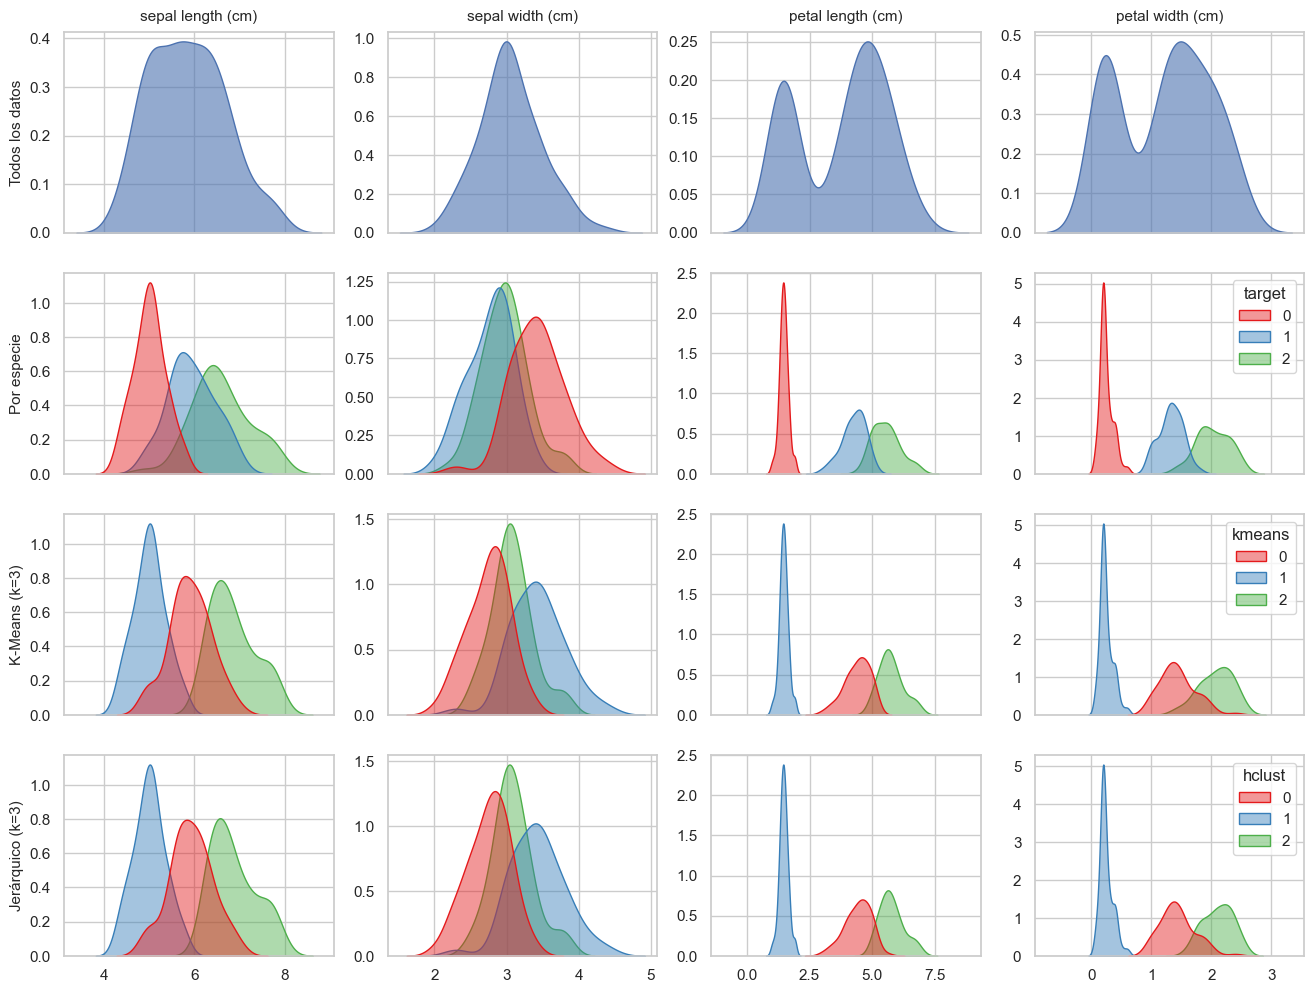

In [88]:
cases = [
    ("Todos los datos", None),
    ("Por especie", "target"),
    ("K-Means (k=3)", "kmeans"),
    ("Jerárquico (k=3)", "hclust"),
]
features = list(X.columns)  # 4 columnas (una por variable)

# --- Estilos ---

fig, axes = plt.subplots(
    nrows=len(cases), ncols=len(features),
    figsize=(16, 12), sharex="col"
)

# Paletas (opcionales) para consistencia entre filas
palette_species = sns.color_palette("Set2", 3)
palette_clusters = sns.color_palette("Set1", 3)

# --- Graficar ---
for i, (row_label, hue_col) in enumerate(cases):
    for j, feat in enumerate(features):
        ax = axes[i, j]

        # Sin color: una sola KDE
        if hue_col is None:
            sns.kdeplot(
                data=iris_df, x=feat, fill=True, alpha=0.6, linewidth=1, ax=ax
            )
        else:
            # Elegir paleta según el tipo de hue
            palette = None
            if hue_col == "species":
                palette = palette_species
            else:
                palette = palette_clusters

            sns.kdeplot(
                data=iris_df, x=feat, hue=hue_col,
                fill=True, common_norm=False, alpha=0.45, linewidth=1, ax=ax,
                palette=palette
            )

        # Títulos de columnas (solo en la primera fila)
        if i == 0:
            ax.set_title(feat, fontsize=11, pad=8)

        # Etiqueta de fila (solo en la primera columna)
        if j == 0:
            ax.set_ylabel(row_label, fontsize=11)
        else:
            ax.set_ylabel(None)

        # Leyendas: solo mostrar en la última columna para evitar clutter
        if j != len(features) - 1:
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()
        else:
            # Ajustar título de la leyenda por estética
            leg = ax.get_legend()
            if leg is not None and hue_col is not None:
                leg.set_title(hue_col)

        # Limpiar detalles menores
        ax.set_xlabel(None)


plt.show()

## ¿Qué es el aprendizaje supervisado? 🎓

---


En el *aprendizaje supervisado* el modelo aprende de datos que sí tienen etiquetas.  
Se entrena con ejemplos donde la respuesta correcta está disponible, y luego puede predecir en nuevos casos.  

> Ejemplo cotidiano: un filtro de spam aprende a reconocer correos “spam” y “no spam” a partir de ejemplos etiquetados.  

---

### Clasificador ⚡
Un clasificador es un modelo de *machine learning* que asigna una etiqueta a cada nueva observación.  
Por ejemplo, dado un correo, puede clasificarlo como *spam* o *no spam*.  

---

### Fases del entrenamiento 🏋️‍♀️

#### Conjunto de entrenamiento y prueba  
Los datos se dividen en dos partes:  
* **Entrenamiento**: donde el modelo aprende.  
* **Prueba**: donde validamos su capacidad de generalizar.  

---



#### Algoritmos de clasificación 📚
Algunos algoritmos muy usados son:  


- **Árbol de decisión 🌳**: reglas jerárquicas que dividen los datos en ramas hasta llegar a una predicción.  




<center>
  <img src="https://algobeans.com/wp-content/uploads/2016/07/decision-tree-tutorial-animated3.gif" alt="Árbol de decisión" style="max-width:50%; height:auto;"  width="50%">
</center>

- **Bosque aleatorio 🌲🌲**: combina muchos árboles para lograr mayor precisión y robustez.  


<center>
  <img src="https://upload.wikimedia.org/wikipedia/commons/c/c7/Randomforests_ensemble.gif" alt="Bosque aleatorio" style="max-width:50%; height:auto;"  width="50%">
</center>

- **Regresión logística 📈**: predice la probabilidad de pertenecer a una clase, muy usado en problemas binarios.  

<center>
  <img src="https://i.redd.it/4hsywapotur91.gif" alt="Árbol de decisión" style="max-width:50%; height:auto;"  width="50%">
</center>

---

#### Entrenamiento ⚙️
El modelo se ajusta usando los datos de entrenamiento para aprender los patrones.  

---

#### Evaluar las predicciones ✅
Con los datos de prueba verificamos qué tan bien clasifica el modelo.  
Las métricas comunes incluyen:  
- *Accuracy*: porcentaje de aciertos.  
- *Precision y Recall*: calidad en clases desbalanceadas.  
- *F1-score*: balance entre precision y recall.  

---

### Ejemplo práctico: Clasificación con el dataset Breast Cancer 🩺🎀

El dataset **Breast Cancer Wisconsin** contiene información clínica de tumores de mama.  
Cada registro describe características extraídas de imágenes de células (por ejemplo: textura, tamaño, radio, simetría).  
La etiqueta indica si el tumor es **benigno** o **maligno**.  

Este dataset es ampliamente usado para ilustrar clasificación supervisada porque:  
- Es real y de gran impacto en la salud.  
- Contiene suficientes ejemplos (más de 500 casos).  
- Tiene variables numéricas fáciles de procesar.  

En nuestro ejercicio:  
1. Dividiremos los datos en entrenamiento y prueba.  
2. Entrenaremos diferentes clasificadores (árbol de decisión, bosque aleatorio, regresión logística).  
3. Compararemos su rendimiento .  

> Ejemplo práctico: el modelo aprende a reconocer patrones en los tumores y luego, dado un nuevo caso, predice si es benigno o maligno.


In [ ]:
def get_confusion_matrix(y_true,y_predict):
    cm = confusion_matrix(y_true=y_true,y_pred=y_predict)
    # 2) Graficar con seaborn
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr", cbar=False)

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title("Matriz de confusión")
    plt.show()

    

In [ ]:
data = load_breast_cancer(as_frame=True)
df = data.frame
X = df.drop(columns=['target'])
y = df['target']

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

In [ ]:
plt.figure(figsize=(12, 6))
plot_tree(tree_model)
plt.show()

In [ ]:
preds_tree = tree_model.predict(X_valid)
print("Accuracy Árbol de Decisión:", accuracy_score(y_valid, preds_tree))

In [ ]:
get_confusion_matrix(y_valid,preds_tree)


In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
preds_rf = rf_model.predict(X_valid)
print("Accuracy Random Forest:", accuracy_score(y_valid, preds_rf))

In [ ]:
get_confusion_matrix(y_valid,preds_rf)

In [ ]:
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)
preds_log = log_model.predict(X_valid)
print("Accuracy Regresión Logística:", accuracy_score(y_valid, preds_log))

In [ ]:
get_confusion_matrix(y_valid,preds_log)

## Para cerrar 💬🤔

----

1. ¿Qué ventajas y limitaciones observaste entre el aprendizaje supervisado y el no supervisado?  
2. Si tuvieras que aplicar Machine Learning en un problema real de tu interés (salud, deportes, negocios, etc.), ¿qué tipo de aprendizaje y algoritmo escogerías y por qué?  


## 🚀 Para seguir aprendiendo :

---

- 📚 Vuelve a revisar este notebook y trata resolver por tu cuenta el proyecto nuevamente
- 💬 Recuerda que en Discord puedes dejar todos tus comentarios y dudas sobre el contenido del sprint en [Sprint 12](https://discord.com/channels/1081207584104656986/1270074296395497513).
    - 📝 Si tienes preguntas sobre tu proyecto, usa el canal `#project` para recibir ayuda y compartir ideas.
    - 🤝 Aprovecha el espacio de `CoLearning` para aclarar tus dudas junto con otros estudiantes e instructores: [Co-Learning](https://discord.com/channels/1081207584104656986/1197953851391746119).
- 📅 ¿Necesitas ayuda personalizada? Puedes agendar una sesión `1:1` conmigo aquí: [1:1 Roman Castillo](https://scheduler.zoom.us/roman-castillo/1-1-roman-castillo).

- Por último hazme paro y responde la encuesta al final de la sesión, me sirve para poder ayudarte mejor 

¡Sigue practicando y no dudes en pedir apoyo cuando lo necesites! 💪✨